### Neural Networks

In [354]:
import pandas as pd
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

rng = np.random.default_rng(42)

In [355]:
train_file_path = "../../input/house-prices-advanced-regression-techniques/train.csv"
test_file_path = "../../input/house-prices-advanced-regression-techniques/test.csv"
train_df = pd.read_csv(train_file_path)
test_df = pd.read_csv(test_file_path)
test_ids = test_df['Id']

# 拼接训练集和测试集特征（去掉 Id 和 SalePrice）
all_features = pd.concat([train_df.drop(['Id', 'SalePrice'], axis=1), 
                          test_df.drop('Id', axis=1)])
n_train = train_df.shape[0]

In [356]:
# 对所有数值特征标准化（训练+测试一起算）
num_features = all_features.select_dtypes(include=[np.number]).columns
all_features[num_features] = all_features[num_features].apply(
    lambda x: (x - x.mean()) / x.std())
all_features[num_features] = all_features[num_features].fillna(0)
# one-hot 编码（dtype=float 防止生成 bool 列导致后续转 tensor 出错）
all_features = pd.get_dummies(all_features, dummy_na=True, dtype=float)
print(all_features.shape)

(2919, 330)


In [357]:
class MyDataset(Dataset):
    def __init__(self, dataset):
        self.X = dataset[:, :-1]
        self.y = dataset[:, -1:]

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [358]:
# 拆分回训练集和测试集
train_features = torch.tensor(all_features[:n_train].values, dtype=torch.float32)
test_features = torch.tensor(all_features[n_train:].values, dtype=torch.float32)
train_labels = torch.tensor(train_df['SalePrice'].values.reshape(-1, 1), dtype=torch.float32)
# 训练用的 dataset: 特征 + 标签拼在一起
dataset = torch.cat([train_features, train_labels], dim=1)
print(f"train: {train_features.shape}, test: {test_features.shape}, labels: {train_labels.shape}")

train: torch.Size([1460, 330]), test: torch.Size([1459, 330]), labels: torch.Size([1460, 1])


In [359]:
def split_dataset(dataset, vali_ratio=0.25):
    vali_indices = rng.random(len(dataset)) < vali_ratio
    return dataset[~vali_indices], dataset[vali_indices]
data_train, data_vali = split_dataset(dataset)

In [360]:
def get_k_fold_dataset(dataset, k=5):
    """
    params:
        dataset: torch.Tensor
        k: int
    return:
        train set, vali set
    """
    n = dataset.shape[0]
    fold_size = n // k
    indices = rng.permutation(n)
    start, end = 0, fold_size
    for _ in range(k):
        vali_idx = indices[start:end]
        train_idx = np.concatenate([indices[:start], indices[end:]])
        yield dataset[train_idx], dataset[vali_idx]
        start += fold_size
        end += fold_size

In [361]:
in_features = train_features.shape[1]

def make_net():
    return nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Linear(256, 1),
    )

loss = nn.MSELoss()

def log_rmse(net, features, labels):
    """d2l 中的对数均方根误差"""
    with torch.no_grad():
        # 将小于1的值设成1，使取对数时数值更稳定
        clipped_preds = torch.clamp(net(features), 1, float('inf'))
        rmse = torch.sqrt(loss(torch.log(clipped_preds), torch.log(labels)))
    return rmse.item()

In [362]:
def train(net, train_features, train_labels, test_features, test_labels,
          epochs, lr, weight_decay, batch_size):
    train_ds = TensorDataset(train_features, train_labels)
    dataloader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(params=net.parameters(), lr=lr, weight_decay=weight_decay)
    
    train_ls, test_ls = [], []
    for _ in range(epochs):
        net.train()
        for X, y in dataloader:
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
        net.eval()
        train_ls.append(log_rmse(net, train_features, train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))
    return train_ls, test_ls

In [363]:
def get_k_fold_data(k, i, X, y):
    """获取第 i 折的训练和验证数据"""
    fold_size = X.shape[0] // k
    X_train, y_train = None, None
    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size)
        X_part, y_part = X[idx], y[idx]
        if j == i:
            X_valid, y_valid = X_part, y_part
        elif X_train is None:
            X_train, y_train = X_part, y_part
        else:
            X_train = torch.cat([X_train, X_part], 0)
            y_train = torch.cat([y_train, y_part], 0)
    return X_train, y_train, X_valid, y_valid

def k_fold(k, X_train, y_train, epochs, lr, weight_decay, batch_size):
    train_l_sum, valid_l_sum = 0, 0
    train_ls_all, valid_ls_all = [], []
    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)
        net = make_net()
        train_ls, valid_ls = train(net, *data, epochs, lr, weight_decay, batch_size)
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        train_ls_all.append(train_ls)
        valid_ls_all.append(valid_ls)
        print(f'  fold {i + 1}, train log rmse {train_ls[-1]:.4f}, valid log rmse {valid_ls[-1]:.4f}')
    return (np.mean(train_ls_all, axis=0), np.mean(valid_ls_all, axis=0),
            train_l_sum / k, valid_l_sum / k)

In [364]:
k, epochs, lr, weight_decay, batch_size = 5, 100, 5, 0, 64
train_loss, vali_loss, avg_train, avg_vali = k_fold(
    k, train_features, train_labels, epochs, lr, weight_decay, batch_size)
print(f'\n{k}-fold: avg train log rmse={avg_train:.4f}, avg valid log rmse={avg_vali:.4f}')

  fold 1, train log rmse 0.1109, valid log rmse 0.1936
  fold 2, train log rmse 0.0345, valid log rmse 0.1735
  fold 3, train log rmse 0.0541, valid log rmse 0.1597
  fold 4, train log rmse 0.1866, valid log rmse 0.2249
  fold 5, train log rmse 0.0365, valid log rmse 0.1628

5-fold: avg train log rmse=0.0845, avg valid log rmse=0.1829


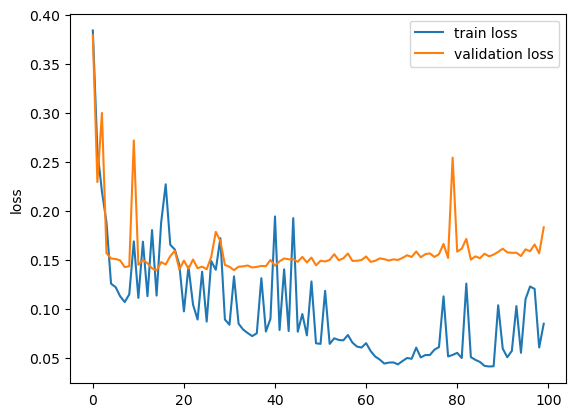

In [365]:
fig, ax = plt.subplots()
x = list(range(len(train_loss)))
ax.plot(x, train_loss, label='train loss')
ax.plot(x, vali_loss, label='validation loss')
ax.set_ylabel('loss')
ax.legend()

In [366]:
print(np.argmin(vali_loss), np.min(vali_loss))

14 0.13880039751529694


In [367]:
from itertools import product

# Step 1: 搜 lr
k, epochs, batch_size = 5, 200, 64
lrs = [1, 5, 10]
print("=== Step 1: 搜索 lr ===")
best_vali, best_lr = float('inf'), None
for lr in lrs:
    _, _, _, avg_vali = k_fold(k, train_features, train_labels, epochs, lr, 0, batch_size)
    print(f"  lr={lr} -> log rmse={avg_vali:.4f}")
    if avg_vali < best_vali:
        best_vali, best_lr = avg_vali, lr
print(f"  Best lr={best_lr}\n")

# Step 2: 固定最佳 lr，搜 weight_decay
weight_decays = [0, 1e-3, 1e-2, 0.1]
print("=== Step 2: 搜索 weight_decay ===")
best_wd = 0
for wd in weight_decays:
    _, _, _, avg_vali = k_fold(k, train_features, train_labels, epochs, best_lr, wd, batch_size)
    print(f"  wd={wd} -> log rmse={avg_vali:.4f}")
    if avg_vali < best_vali:
        best_vali, best_wd = avg_vali, wd
print(f"  Best wd={best_wd}\n")

print(f"=== 最优参数: lr={best_lr}, weight_decay={best_wd}, log rmse={best_vali:.4f} ===")

=== Step 1: 搜索 lr ===
  fold 1, train log rmse 0.0531, valid log rmse 0.2143
  fold 2, train log rmse 0.0501, valid log rmse 0.1811
  fold 3, train log rmse 0.0368, valid log rmse 0.1885
  fold 4, train log rmse 0.0282, valid log rmse 0.1398
  fold 5, train log rmse 0.0347, valid log rmse 0.1810
  lr=1 -> log rmse=0.1809
  fold 1, train log rmse 0.0636, valid log rmse 0.1507
  fold 2, train log rmse 0.0324, valid log rmse 0.1885
  fold 3, train log rmse 0.0437, valid log rmse 0.1680
  fold 4, train log rmse 0.0794, valid log rmse 0.1751
  fold 5, train log rmse 0.0208, valid log rmse 0.1597
  lr=5 -> log rmse=0.1684
  fold 1, train log rmse 0.0941, valid log rmse 0.1690
  fold 2, train log rmse 0.0763, valid log rmse 0.2262
  fold 3, train log rmse 0.0796, valid log rmse 0.2005
  fold 4, train log rmse 0.0955, valid log rmse 0.1467
  fold 5, train log rmse 0.0862, valid log rmse 0.1851
  lr=10 -> log rmse=0.1855
  Best lr=5

=== Step 2: 搜索 weight_decay ===
  fold 1, train log rmse 0.03

In [368]:
"""# 用全部训练数据重新训练，预测测试集并生成提交文件
def train_and_pred(train_features, test_features, train_labels, test_ids,
                   epochs, lr, weight_decay, batch_size):
    net = make_net()
    train_ls, _ = train(net, train_features, train_labels, None, None,
                        epochs, lr, weight_decay, batch_size)
    print(f'train log rmse: {train_ls[-1]:.4f}')
    
    net.eval()
    preds = net(test_features).detach().numpy()
    submission = pd.DataFrame({'Id': test_ids, 'SalePrice': preds.flatten()})
    submission.to_csv('submission.csv', index=False)
    print('submission.csv saved')

train_and_pred(train_features, test_features, train_labels, test_ids,
               epochs=100, lr=5, weight_decay=0, batch_size=64)"""

"# 用全部训练数据重新训练，预测测试集并生成提交文件\ndef train_and_pred(train_features, test_features, train_labels, test_ids,\n                   epochs, lr, weight_decay, batch_size):\n    net = make_net()\n    train_ls, _ = train(net, train_features, train_labels, None, None,\n                        epochs, lr, weight_decay, batch_size)\n    print(f'train log rmse: {train_ls[-1]:.4f}')\n\n    net.eval()\n    preds = net(test_features).detach().numpy()\n    submission = pd.DataFrame({'Id': test_ids, 'SalePrice': preds.flatten()})\n    submission.to_csv('submission.csv', index=False)\n    print('submission.csv saved')\n\ntrain_and_pred(train_features, test_features, train_labels, test_ids,\n               epochs=100, lr=5, weight_decay=0, batch_size=64)"